# Анализ данных VK для дообучения VLM

В этом ноутбуке изучается открытый набор `deepvk/LLaVA-Instruct-ru`. Цель — понять его структуру, проверить примеры и выбрать воспроизводимую подвыборку для первой итерации QLoRA-дообучения.

**Правило эксперимента:** этот набор используется только для обучения. `GQA-ru` и `MMBench-ru` останутся независимыми наборами для оценки модели после обучения.

## 1. Загрузка и устройство данных

В карточке датасета указаны поля `type`, `conversations`, `id` и `image`. Изображения не включены в JSON: поле `image` содержит путь к соответствующему изображению COCO. Поэтому для общего анализа достаточно метаданных, а для визуальной проверки далее загрузим несколько изображений по открытым ссылкам COCO.

In [1]:
from collections import Counter
from pathlib import Path
import json
import re

import matplotlib.pyplot as plt
import pandas as pd
import requests
import seaborn as sns
from IPython.display import Markdown, display
from PIL import Image
from io import BytesIO

RANDOM_SEED = 42
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = ROOT / 'data' / 'raw'
FIGURES_DIR = ROOT / 'results' / 'figures'
SUBSET_DIR = ROOT / 'data' / 'processed'
for directory in (DATA_DIR, FIGURES_DIR, SUBSET_DIR):
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='deep')
pd.set_option('display.max_colwidth', 140)

In [2]:
FILES = {
    'train': 'llava_instruct_ru_train.json',
    'validation': 'llava_instruct_ru_val.json',
}
BASE_URL = 'https://huggingface.co/datasets/deepvk/LLaVA-Instruct-ru/resolve/main/'

def download_if_needed(filename):
    target = DATA_DIR / filename
    if target.exists() and target.stat().st_size > 1_000_000:
        print(f'Уже загружен: {target.name} ({target.stat().st_size / 1e6:.1f} МБ)')
        return target
    print(f'Скачиваю {filename}...')
    with requests.get(BASE_URL + filename, stream=True, timeout=120) as response:
        response.raise_for_status()
        with open(target, 'wb') as file:
            for chunk in response.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    file.write(chunk)
    print(f'Готово: {target.stat().st_size / 1e6:.1f} МБ')
    return target

paths = {split: download_if_needed(filename) for split, filename in FILES.items()}
raw_splits = {split: json.loads(path.read_text(encoding='utf-8')) for split, path in paths.items()}
{split: len(rows) for split, rows in raw_splits.items()}

Скачиваю llava_instruct_ru_train.json...


Готово: 196.7 МБ
Скачиваю llava_instruct_ru_val.json...


Готово: 77.7 МБ


{'train': 109905, 'validation': 34075}

In [3]:
# Один исходный пример: два сообщения — вопрос человека и ответ модели-учителя.
example = raw_splits['train'][0]
example

{'image': 'coco/train2017/000000253464.jpg',
 'conversations': [{'from': 'human',
   'value': '<image>\nЧто делает обстановку этой ванны такой особенной по сравнению с другими?'},
  {'from': 'gpt',
   'value': 'Эта ванная комната выделяется своей чистотой и опрятностью. На изображении видно, что ванная идеально чистая, свет включен. Наличие цветов, стоящих на столешнице, добавляет элемент уюта и свежести в интерьер. Деревянные шкафчики придают теплоту и натуральность обстановке. Зелено-белый полосатый душевой занавес создает яркий акцент и придает привлекательность дизайну ванной комнаты.'}],
 'id': '000000253464',
 'type': 'complex_reasoning'}

In [4]:
def to_row(record, split, row_number):
    messages = record['conversations']
    question = next((item['value'] for item in messages if item['from'] == 'human'), '')
    answer = next((item['value'] for item in messages if item['from'] == 'gpt'), '')
    return {
        'split': split,
        'row_number': row_number,
        'type': record['type'],
        'image_id': record['id'],
        'image_path': record['image'],
        'question': question.replace('<image>\n', '').strip(),
        'answer': answer.strip(),
        'question_chars': len(question.replace('<image>\n', '').strip()),
        'answer_chars': len(answer.strip()),
        'question_words': len(question.replace('<image>\n', '').split()),
        'answer_words': len(answer.split()),
    }

frames = [
    pd.DataFrame(to_row(record, split, i) for i, record in enumerate(records))
    for split, records in raw_splits.items()
]
df = pd.concat(frames, ignore_index=True)
df.head(3)

,split,row_number,type,image_id,image_path,question,answer,question_chars,answer_chars,question_words,answer_words
0,train,0,complex_reasoning,000000253464,coco/train2017/000000253464.jpg,Что делает обстановку этой ванны такой особенной по сравнению с другими?,"Эта ванная комната выделяется своей чистотой и опрятностью. На изображении видно, что ванная идеально чистая, свет включен. Наличие цвет...",72,384,11,49
1,train,1,complex_reasoning,000000266366,coco/train2017/000000266366.jpg,Какие особенности делают умывальник в этой ванной комнате интересным?,Умывальник в этой ванной комнате привлекает внимание своим дизайном и особенностями. Он имеет характерную форму и расположен на стильной...,69,484,9,62
2,train,2,complex_reasoning,000000372427,coco/train2017/000000372427.jpg,"Что может вызвать дополнительное удовольствие у человека, находящегося в этой ванной комнате?","Для человека, находящегося в этой ванной комнате, дополнительное удовольствие может вызвать возможность наслаждаться видом на снежный де...",93,636,12,83


## 2. Размер и состав датасета

,split,examples
0,train,109905
1,validation,34075


,split,type,examples
0,train,complex_reasoning,70993
1,train,conversation,38912
2,validation,conversation,34075


Всего примеров: 143,980
Уникальных путей к изображениям: 109,617
Дубликатов изображений между примерами: 34,363


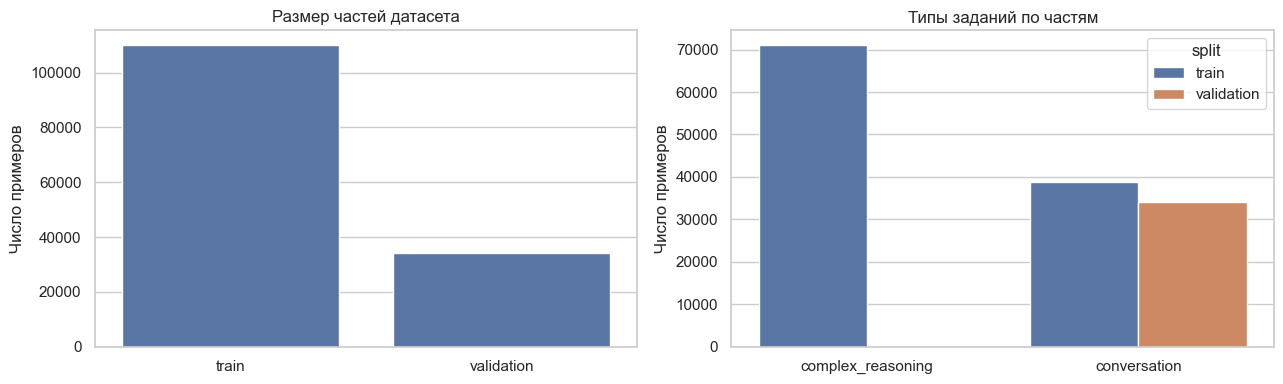

In [5]:
split_counts = df['split'].value_counts().rename_axis('split').reset_index(name='examples')
type_counts = (df.groupby(['split', 'type']).size().rename('examples').reset_index()
                .sort_values(['split', 'examples'], ascending=[True, False]))

display(split_counts)
display(type_counts)
print(f'Всего примеров: {len(df):,}')
print(f'Уникальных путей к изображениям: {df.image_path.nunique():,}')
print(f'Дубликатов изображений между примерами: {len(df) - df.image_path.nunique():,}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=split_counts, x='split', y='examples', ax=axes[0])
axes[0].set(title='Размер частей датасета', xlabel='', ylabel='Число примеров')
sns.barplot(data=type_counts, x='type', y='examples', hue='split', ax=axes[1])
axes[1].set(title='Типы заданий по частям', xlabel='', ylabel='Число примеров')
for ax in axes:
    ax.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_dataset_structure.png', dpi=160, bbox_inches='tight')
plt.show()

## 3. Вопросы и ответы

Для быстрой типологии вопроса используем первое слово после удаления токена изображения. Это не идеальная лингвистическая классификация, но она позволяет увидеть, какие формулировки преобладают и нужны ли специальные шаблоны при подготовке данных.

,первое слово,examples
0,какие,33213
1,что,32078
2,сколько,29476
3,на,5680
4,как,5113
5,какой,4814
6,какого,4592
7,какое,4046
8,чем,3711
9,почему,3040


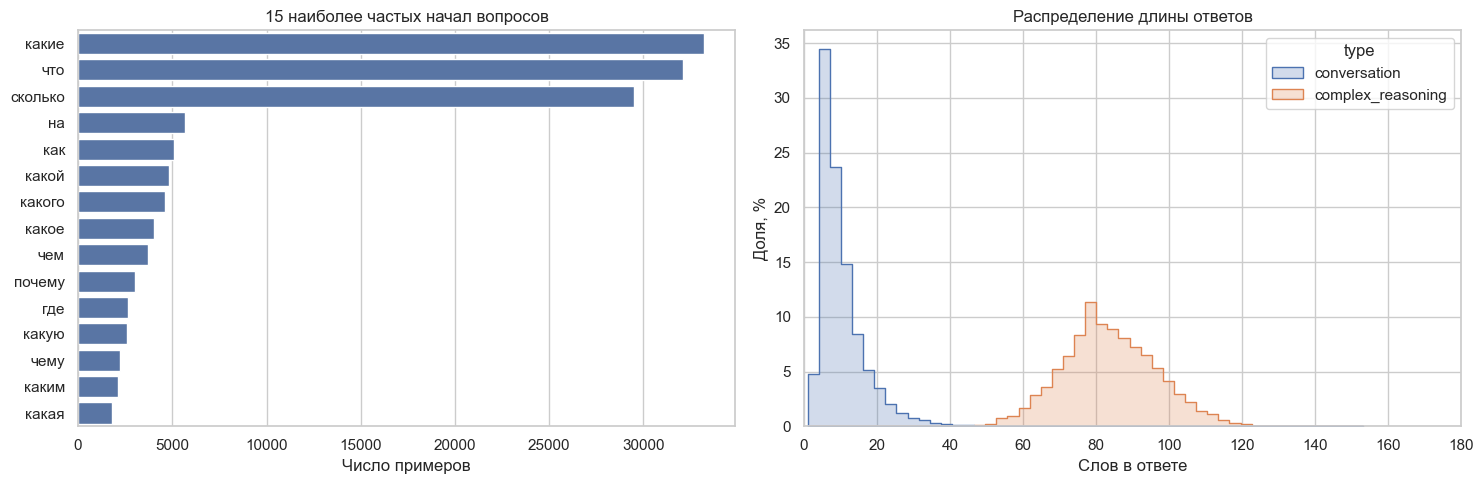

question_words           answer_words             \
                          median  mean max       median  mean  max   
type                                                                 
complex_reasoning           10.0  10.4  26         83.0  83.6  173   
conversation                 6.0   6.7  22          9.0  10.5   99   

                  question_chars            answer_chars               
                          median  mean  max       median   mean   max  
type                                                                   
complex_reasoning           70.0  71.7  191        608.0  613.1  1403  
conversation                45.0  46.9  141         60.0   73.2   824

In [6]:
def first_word(text):
    match = re.search(r'[А-Яа-яA-Za-zЁё]+', text)
    return match.group(0).lower() if match else 'другое'

df['question_start'] = df['question'].map(first_word)
top_starts = df['question_start'].value_counts().head(15).rename_axis('первое слово').reset_index(name='examples')
display(top_starts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=top_starts, y='первое слово', x='examples', ax=axes[0], color='#4C72B0')
axes[0].set(title='15 наиболее частых начал вопросов', xlabel='Число примеров', ylabel='')

plot_data = df.sample(min(25_000, len(df)), random_state=RANDOM_SEED)
sns.histplot(data=plot_data, x='answer_words', hue='type', bins=50, element='step', stat='percent', common_norm=False, ax=axes[1])
axes[1].set(title='Распределение длины ответов', xlabel='Слов в ответе', xlim=(0, 180), ylabel='Доля, %')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_question_and_answer_lengths.png', dpi=160, bbox_inches='tight')
plt.show()

length_summary = df.groupby('type')[['question_words', 'answer_words', 'question_chars', 'answer_chars']].agg(['median', 'mean', 'max']).round(1)
length_summary

## 4. Визуальная проверка

Ниже случайно, но воспроизводимо выбираются примеры обоих типов. Это проверяет, что путь к изображению соответствует диалогу и что в вопросе присутствует служебный токен `<image>`, который затем потребуется обработать в шаблоне выбранной модели.

C:\Users\miste\AppData\Local\Temp\ipykernel_12684\184500068.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group.sample(min(2, len(group)), random_state=RANDOM_SEED))


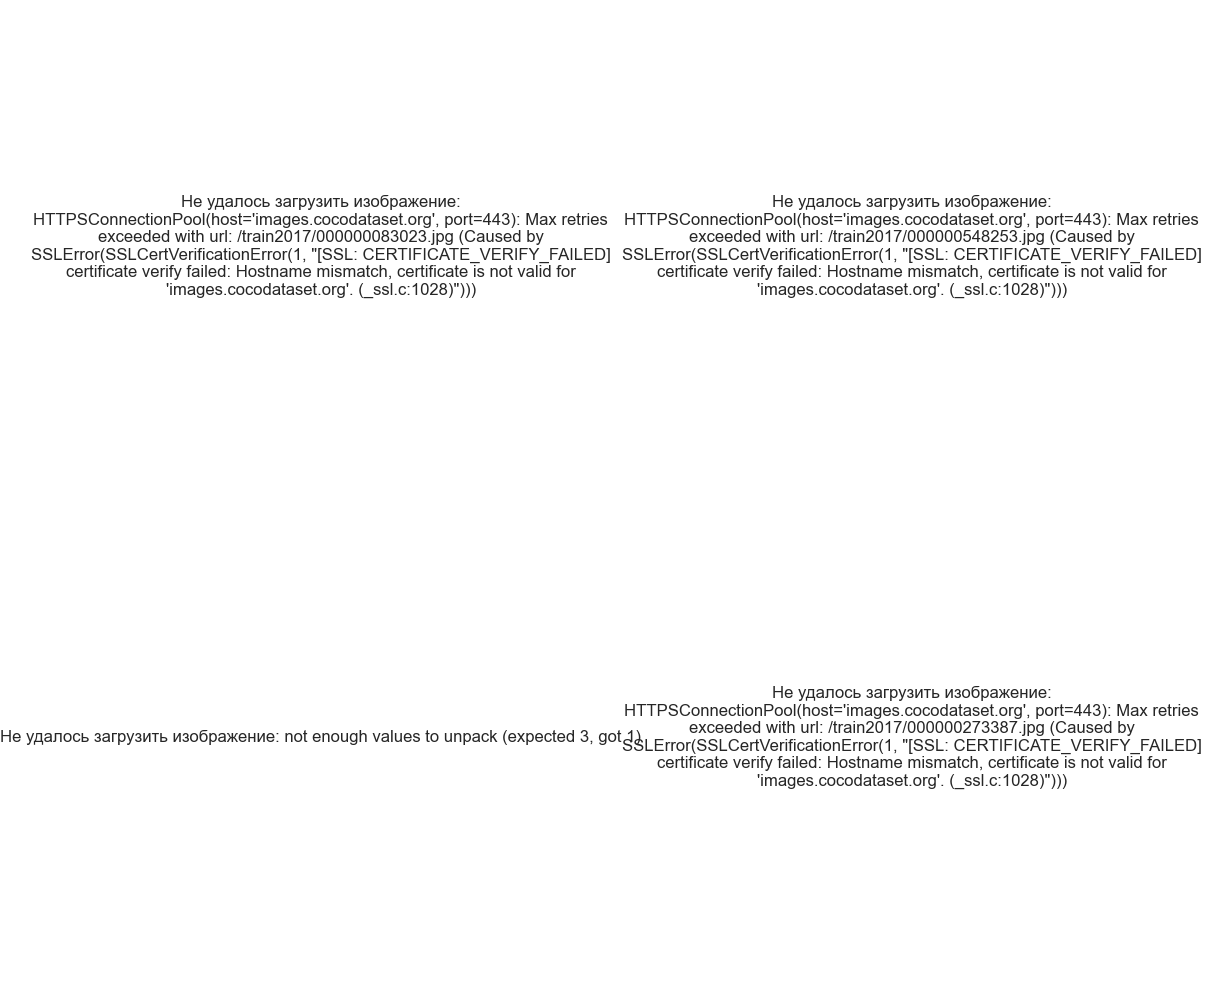

**Тип:** `complex_reasoning`  
+**Вопрос:** Какие аспекты безопасности следует учитывать при занятии подобным видом активности на открытом пространстве?  
+**Ответ:** При занятии полетом воздушного змея на открытом пространстве следует учитывать несколько аспектов безопасности. Во-первых, важно обеспечить безопасное расстояние между человеком, управляющим воздушным змеем, и другими людьми или объектами, чтобы избежать возможного столкновения или травм. Кроме того, необходимо учитывать погодные условия, такие как силу ветра, чтобы избежать того, чтобы воздушный змей вышел из-под контроля. Также важно иметь в виду, что занятие этим видом активности на открытом пространстве требует некоторой подготовки и навыков, чтобы успешно и безопасно управлять воздушным змеем. Важно также выбирать безопасные места для полета воздушного змея, чтобы минимизировать риски для окружающих.

**Тип:** `complex_reasoning`  
+**Вопрос:** Какие особенности движения транспорта и пассажиропотока видны на фотографии?  
+**Ответ:** На изображении видно, что страна, в которой происходит сцена, является левосторонней для движения транспорта. Несколько автомобилей остановились на автобусной остановке перед зданием Barclays, а рядом стоит двухэтажный автобус. Автобус также стоит на городской дороге, чтобы пассажиры могли сойти и сесть. На улице также видно несколько человек, прибывших на автобусную остановку в ожидании транспорта. Такая ситуация подчеркивает популярность общественного транспорта и большое количество людей, использующих автобусы для передвижения по городу. Размещение транспорта и людей около остановки свидетельствует о жизненном ритме города и контрасте между напряженной городской средой и доступностью общественного транспорта для жителей и посетителей.

**Тип:** `conversation`  
+**Вопрос:** Какие цвета преобладают на поезде, который находится на пустой железнодорожной станции?  
+**Ответ:** На поезде, который находится на пустой железнодорожной станции, преобладают белый, желтый и синий цвета.

**Тип:** `conversation`  
+**Вопрос:** Какое животное изображено на фото в тени деревьев?  
+**Ответ:** На фото изображен одинокий конь.

In [7]:
def coco_url(image_path):
    # Путь имеет вид coco/train2017/000000000000.jpg.
    _, split, filename = image_path.split('/')
    return f'https://images.cocodataset.org/{split}/{filename}'

visual_rows = (df.groupby('type', group_keys=False)
                 .apply(lambda group: group.sample(min(2, len(group)), random_state=RANDOM_SEED))
                 .reset_index(drop=True))

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (_, row) in zip(axes.ravel(), visual_rows.iterrows()):
    try:
        response = requests.get(coco_url(row.image_path), timeout=30)
        response.raise_for_status()
        image = Image.open(BytesIO(response.content)).convert('RGB')
        ax.imshow(image)
        ax.set_title(f"{row['type']} | id={row['image_id']}", fontsize=10)
    except Exception as error:
        ax.text(0.5, 0.5, f'Не удалось загрузить изображение: {error}', ha='center', va='center', wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_visual_examples.png', dpi=160, bbox_inches='tight')
plt.show()

for _, row in visual_rows.iterrows():
    display(Markdown(f"**Тип:** `{row['type']}`  \n+**Вопрос:** {row['question']}  \n+**Ответ:** {row['answer']}"))

## 5. Подвыборка для первой итерации

Первая итерация нужна для проверки всего цикла: загрузка модели, подготовка мультимодального батча, QLoRA-обучение, сохранение адаптера и оценка. Выбираем **12 000** обучающих примеров с фиксированным `seed=42`, сохраняя пропорции типов заданий. Валидационная часть этого набора не используется: итоговая проверка будет проводиться на GQA-ru и MMBench-ru.

In [8]:
TRAINING_EXAMPLES = 12_000
train_df = df.query("split == 'train'").copy()

# Квоты пропорциональны исходному распределению и в сумме дают ровно 12 000.
proportions = train_df['type'].value_counts(normalize=True)
quotas = (proportions * TRAINING_EXAMPLES).round().astype(int)
quotas.iloc[0] += TRAINING_EXAMPLES - quotas.sum()

subset = pd.concat([
    group.sample(n=quotas[group_name], random_state=RANDOM_SEED)
    for group_name, group in train_df.groupby('type')
]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

subset_path = SUBSET_DIR / 'llava_instruct_ru_first_iteration_seed42.csv'
subset[['row_number', 'type', 'image_id', 'image_path', 'question', 'answer']].to_csv(subset_path, index=False)

subset_counts = subset['type'].value_counts().rename_axis('type').reset_index(name='examples')
display(subset_counts)
print(f'Файл подвыборки: {subset_path}')
print(f'Размер подвыборки: {len(subset):,} из {len(train_df):,} обучающих примеров ({len(subset) / len(train_df):.1%})')

display(Markdown(
    f"### Выводы первой итерации\n"
    f"- В `LLaVA-Instruct-ru` загружено **{len(df):,}** русскоязычных примеров.\n"
    f"- Вопросы и ответы заметно различаются по длине между типами `{', '.join(sorted(df.type.unique()))}`; при обучении нельзя обрезать ответы слишком агрессивно.\n"
    f"- Визуальная проверка подтвердила связку COCO-изображения и русскоязычного диалога.\n"
    f"- Для первого запуска выбрана стратифицированная подвыборка **{len(subset):,}** примеров с фиксированным seed={RANDOM_SEED}."
))

,type,examples
0,complex_reasoning,7751
1,conversation,4249


Файл подвыборки: D:\Projects\VK-VLM-Project\data\processed\llava_instruct_ru_first_iteration_seed42.csv
Размер подвыборки: 12,000 из 109,905 обучающих примеров (10.9%)


### Выводы первой итерации
- В `LLaVA-Instruct-ru` загружено **143,980** русскоязычных примеров.
- Вопросы и ответы заметно различаются по длине между типами `complex_reasoning, conversation`; при обучении нельзя обрезать ответы слишком агрессивно.
- Визуальная проверка подтвердила связку COCO-изображения и русскоязычного диалога.
- Для первого запуска выбрана стратифицированная подвыборка **12,000** примеров с фиксированным seed=42.